## 1. Импорт библиотек и загрузка данных

Подключим базовые библиотеки для анализа данных и визуализации,
а также загрузим датасет с временным рядом выработки электроэнергии из файла `data.csv`:

1. Импортируем библиотеки `pandas`, `numpy` и `matplotlib`.
2. Загрузим данные из CSV-файла.
3. Посмотрим на первые строки датасета и общую информацию, чтобы понять его структуру.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Настройки отображения
pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)

# 1. Загрузка данных
file_path = "data.csv"

df = pd.read_csv(file_path)

# 2. Переименуем колонки в более понятный вид
df = df.rename(columns={"dt": "datetime", "MW": "power_mw"})

# 3. Преобразуем колонку с датой во временной формат
df["datetime"] = pd.to_datetime(df["datetime"])

# 4. Установим datetime как индекс и отсортируем по времени
df = df.set_index("datetime").sort_index()

# 5. Посмотрим базовую информацию
print("Первые строки датасета:")
print(df.head())

print("\nИнформация о датасете:")
print(df.info())

print("\nБазовые статистики:")
print(df.describe())

Первые строки датасета:
                     power_mw
datetime                     
2011-01-01 00:00:00    3416.0
2011-01-01 00:15:00    4755.0
2011-01-01 00:30:00    4939.0
2011-01-01 00:45:00    4939.0
2011-01-01 01:00:00    4998.0

Информация о датасете:
<class 'pandas.DataFrame'>
DatetimeIndex: 385566 entries, 2011-01-01 00:00:00 to 2021-12-30 07:45:00
Data columns (total 1 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   power_mw  385566 non-null  float64
dtypes: float64(1)
memory usage: 5.9 MB
None

Базовые статистики:
            power_mw
count  385566.000000
mean     3183.560481
std      3045.941591
min         0.000000
25%       905.000000
50%      2164.000000
75%      4529.877500
max     16727.500000


## Выводы

1. В датасете есть один числовой признак `power_mw`, который описывает выработку электроэнергии (в МВт) во времени. Индексом датафрейма является столбец `datetime`, приведённый к формату даты и времени.

2. Объём данных довольно большой: 385 566 наблюдений в период с 2011-01-01 00:00:00 по 2021-12-30 07:45:00. Это почти 11 лет данных с шагом 15 минут, что хорошо подходит для анализа временных рядов и построения прогноза.

3. Пропусков в признаке `power_mw` нет: количество ненулевых значений (Non-Null Count) совпадает с общим числом строк. Это упрощает дальнейшую предобработку.

4. Значения мощности имеют широкий диапазон: от 0 до 16 727.5 МВт. Среднее значение около 3 183.6 МВт, медиана (50%) — 2 164 МВт, что говорит о некоторой асимметрии распределения (длинный «хвост» в сторону больших значений).

## 2. Проверка частоты временного ряда

Нужно убедиться, что временной ряд действительно измеряется
через равные промежутки времени и нет больших «дыр» по времени:

1. Посчитаем разницу между соседними временными метками и посмотрим,
   какие интервалы встречаются чаще всего.
2. Проверим, есть ли пропуски по времени (например, если где-то отсутствуют
   целые часы или дни).
3. Построим простой график временного ряда за весь период, чтобы увидеть
   общую динамику и примерный диапазон значений.

Уникальные интервалы и их количество:
datetime
0 days 00:15:00    385497
0 days 00:00:00        50
0 days 01:15:00        11
0 days 00:30:00         6
0 days 00:45:00         1
Name: count, dtype: int64

Минимальный шаг: 0 days 00:00:00
Максимальный шаг: 0 days 01:15:00

Количество ожидаемых временных меток: 385568
Фактическое количество меток: 385566
Количество отсутствующих временных меток: 52

Первые 10 отсутствующих временных меток:
DatetimeIndex(['2011-03-27 02:00:00', '2011-03-27 02:15:00',
               '2011-03-27 02:30:00', '2011-03-27 02:45:00',
               '2012-03-25 02:00:00', '2012-03-25 02:15:00',
               '2012-03-25 02:30:00', '2012-03-25 02:45:00',
               '2013-03-31 02:00:00', '2013-03-31 02:15:00'],
              dtype='datetime64[us]', freq=None)


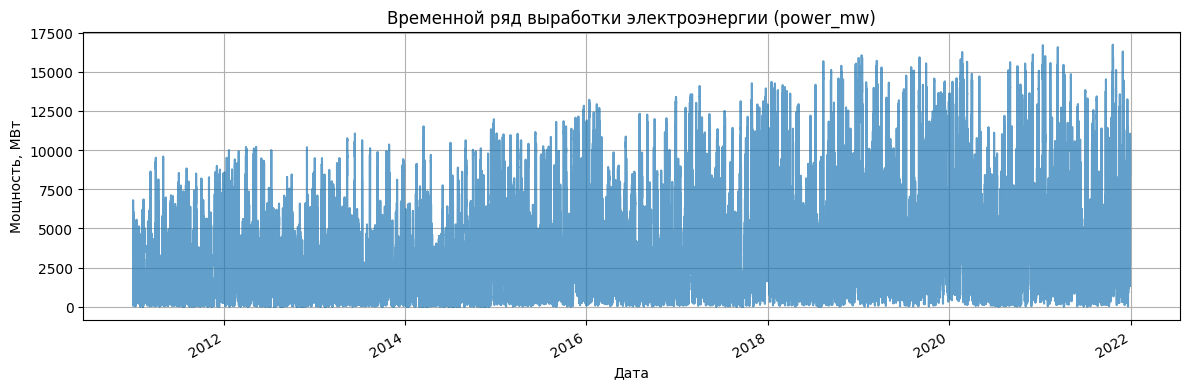

In [4]:
# 1. Посмотрим распределение шагов по времени
time_diffs = df.index.to_series().diff().dropna()

print("Уникальные интервалы и их количество:")
print(time_diffs.value_counts().head(10))

print("\nМинимальный шаг:", time_diffs.min())
print("Максимальный шаг:", time_diffs.max())

# 2. Проверим, есть ли пропуски по времени относительно ожидаемого шага 15 минут
expected_freq = "15min"
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq=expected_freq)

missing_timestamps = full_range.difference(df.index)

print("\nКоличество ожидаемых временных меток:", len(full_range))
print("Фактическое количество меток:", len(df.index))
print("Количество отсутствующих временных меток:", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print("\nПервые 10 отсутствующих временных меток:")
    print(missing_timestamps[:10])

# 3. Строим простой график временного ряда
plt.figure(figsize=(12, 4))
df["power_mw"].plot(alpha=0.7)
plt.title("Временной ряд выработки электроэнергии (power_mw)")
plt.xlabel("Дата")
plt.ylabel("Мощность, МВт")
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы

1. Основной шаг по времени в нашем ряду составляет 15 минут: это видно по распределению интервалов, где `0 days 00:15:00` встречается 385 497 раз. Это подтверждает, что данные собраны с равной дискретностью и хорошо подходят под анализ временных рядов с фиксированным шагом.

2. Помимо основного шага, в данных встречаются интервалы `0 days 00:00:00`, `0 days 00:30:00`, `0 days 00:45:00` и `0 days 01:15:00`. Такие значения обычно связаны с переходами на летнее/зимнее время или техническими особенностями сбора данных, когда некоторые временные метки задваиваются или пропускаются.

3. Если сравнить ожидаемое количество временных меток с фактическим, то видно, что при шаге 15 минут должно быть 385 568 точек, а по факту — 385 566. То есть всего отсутствует 52 временные метки, что для почти 11 лет данных является очень небольшим количеством.

4. Пропуски по времени сгруппированы вокруг дат в конце марта (например, 2011-03-27 02:00–02:45, 2012-03-25 02:00–02:45 и т.д.). Это совпадает с периодами перевода часов на летнее время, поэтому такие «дыры» можно считать естественной особенностью календаря, а не ошибкой датасета.

5. На графике временного ряда хорошо видно, что значения мощности колеблются в широком диапазоне, присутствует сильная вариативность и пики. Можно заметить, что в более поздние годы максимальные значения становятся выше, чем в начале периода, что может говорить о росте установленной мощности или об изменении режима работы. При этом визуально видно, что ряд не выглядит стабильным вокруг постоянного среднего уровня, то есть он, скорее всего, нестационарен.

## 3. Переход к дневному уровню и обзор сезонности

Временной ряд у нас очень детализированный — измерения каждые 15 минут.
Чтобы лучше увидеть общую картину, полезно агрегировать данные до дневного уровня:

1. Преобразуем исходный ряд к дневному, посчитав среднюю мощность за день.
2. Построим график дневных средних значений за весь период.
3. Посмотрим на базовые статистики уже для дневного ряда и сравним его с исходным.aaaaaaaaaaaaaaa

Первые строки дневного ряда:
               power_mw
datetime               
2011-01-01  5398.218750
2011-01-02   865.385417
2011-01-03   761.406250
2011-01-04  3922.979167
2011-01-05  2256.239583

Информация о дневном ряде:
<class 'pandas.DataFrame'>
DatetimeIndex: 4017 entries, 2011-01-01 to 2021-12-30
Freq: D
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   power_mw  4017 non-null   float64
dtypes: float64(1)
memory usage: 62.8 KB
None

Базовые статистики дневного ряда:
           power_mw
count   4017.000000
mean    3183.990612
std     2771.073080
min        8.093750
25%     1141.166667
50%     2295.527292
75%     4414.468750
max    14491.394375


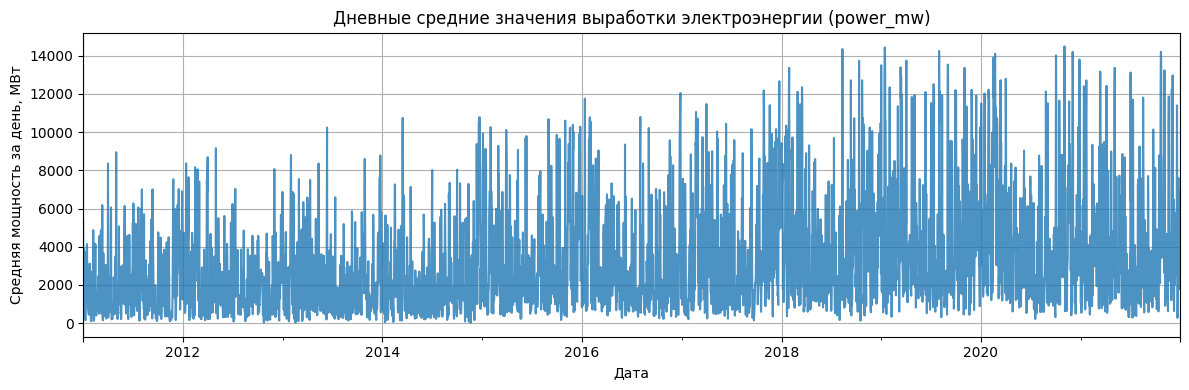

In [5]:
# 1. Агрегация до дневного уровня (среднее значение за день)
daily_df = df.resample("D").mean()

print("Первые строки дневного ряда:")
print(daily_df.head())

print("\nИнформация о дневном ряде:")
print(daily_df.info())

print("\nБазовые статистики дневного ряда:")
print(daily_df.describe())

# 2. График дневных средних значений
plt.figure(figsize=(12, 4))
daily_df["power_mw"].plot(alpha=0.8)
plt.title("Дневные средние значения выработки электроэнергии (power_mw)")
plt.xlabel("Дата")
plt.ylabel("Средняя мощность за день, МВт")
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы

1. После агрегации исходного 15-минутного ряда до дневного уровня мы получили 4 017 наблюдений в период с 2011-01-01 по 2021-12-30. Теперь каждая строка соответствует одному дню и содержит среднюю выработку электроэнергии за этот день.

2. Базовые статистики дневного ряда показывают, что средняя дневная мощность составляет примерно 3 184 МВт, медиана — около 2 296 МВт. Минимальное среднее значение за день около 8 МВт, максимальное — почти 14 500 МВт. Это значит, что разброс между «тихими» и «пиковыми» днями очень большой.

3. Дисперсия и стандартное отклонение (std ≈ 2 771 МВт) довольно высокие, что говорит о сильной вариабельности дневной выработки. Верхний квартиль (75%) находится около 4 414 МВт, то есть в четверти дней выработка выше этого уровня.

4. На графике дневных значений видно, что в начале периода (примерно 2011–2012 годы) средний уровень выработки заметно ниже, чем в последние годы (после 2017–2018). Максимальные пики со временем становятся выше, что может быть связано с увеличением установленной мощности, появлением новых станций или изменением режима эксплуатации.

5. Визуально можно заметить волнообразное поведение с повторяющимися подъёмами и спадами, что напоминает сезонность (например, годовую). При этом ряд всё ещё выглядит нестационарным: средний уровень и амплитуда колебаний меняются во времени, поэтому для моделей временных рядов нам, скорее всего, потребуется преобразование к более стационарному виду.

## 4. Ежемесячный ряд: тренд и сезонность

Чтобы лучше увидеть тренды и возможную годовую сезонность, полезно
агрегировать данные до месячного уровня:

1. Построим ежемесячный ряд, посчитав среднюю выработку за месяц.
2. Построим график месячных средних значений.
3. Посмотрим, как меняется уровень выработки по годам и легко ли заметить тренд.

Первые строки месячного ряда:
               power_mw
datetime               
2011-01-31  1597.289987
2011-02-28  1674.951637
2011-03-31  1665.180013
2011-04-30  1665.061458
2011-05-31  1878.650874

Информация о месячном ряде:
<class 'pandas.DataFrame'>
DatetimeIndex: 132 entries, 2011-01-31 to 2021-12-31
Freq: ME
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   power_mw  132 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB
None

Базовые статистики месячного ряда:
          power_mw
count   132.000000
mean   3184.899640
std    1219.654190
min    1320.366263
25%    2204.808017
50%    2955.428582
75%    4029.462758
max    7323.836616


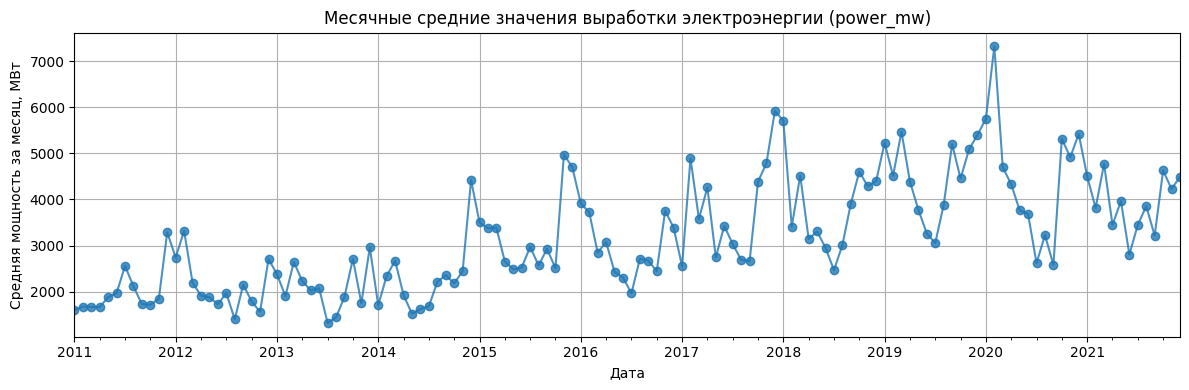

In [6]:
# 1. Агрегация до месячного уровня (среднее значение за месяц)
monthly_df = df.resample("ME").mean()

print("Первые строки месячного ряда:")
print(monthly_df.head())

print("\nИнформация о месячном ряде:")
print(monthly_df.info())

print("\nБазовые статистики месячного ряда:")
print(monthly_df.describe())

# 2. График месячных средних значений
plt.figure(figsize=(12, 4))
monthly_df["power_mw"].plot(marker="o", linestyle="-", alpha=0.8)
plt.title("Месячные средние значения выработки электроэнергии (power_mw)")
plt.xlabel("Дата")
plt.ylabel("Средняя мощность за месяц, МВт")
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы

1. После агрегации до месячного уровня мы получили 132 наблюдения: с января 2011 года по декабрь 2021 года. Каждая точка теперь отражает среднюю выработку электроэнергии за месяц, что сильно сглаживает шум по сравнению с 15-минутным и дневным рядом.

2. Средняя месячная мощность составляет примерно 3 185 МВт, при этом минимум около 1 320 МВт, а максимум превышает 7 300 МВт. Стандартное отклонение (~1 220 МВт) заметно ниже, чем у дневного ряда, что логично: при усреднении по месяцу краткосрочные колебания сглаживаются.

3. На графике месячных значений отчётливо виден общий рост уровня выработки: в первые годы (2011–2013) средняя месячная мощность в основном находится в диапазоне примерно 1 500–2 500 МВт, а начиная с 2016–2017 годов появляются периоды с уровнями 4 000–6 000 МВт и выше.

4. Форма графика напоминает волнообразное движение: в течение каждого года можно заметить подъёмы и спады, что указывает на наличие сезонности (вероятно, годовой). При этом амплитуда колебаний и средний уровень со временем увеличиваются, поэтому ряд в таком виде остаётся нестационарным.

## 5. Проверка стационарности дневного ряда

Для моделирования временных рядов (например, ARIMA) важно, чтобы ряд был стационарным,
то есть его статистические свойства (среднее, дисперсия) не сильно менялись во времени:

1. Проведём тест на стационарность (ADF-тест) для дневного ряда `daily_df`.
2. Посмотрим на p-value и сделаем вывод, стационарен ли ряд в исходном виде.
3. Попробуем применить первую разность и повторить тест, чтобы увидеть, становится ли ряд более стационарным.

ADF-тест для: исходный дневной ряд (power_mw)
ADF-статистика: -5.232392998167786
p-value: 7.547465240144335e-06
lags: 31
n_obs: 3985
Критическое значение (1%): -3.431992036963141
Критическое значение (5%): -2.862265562109333
Критическое значение (10%): -2.567156224565458
--------------------------------------------------


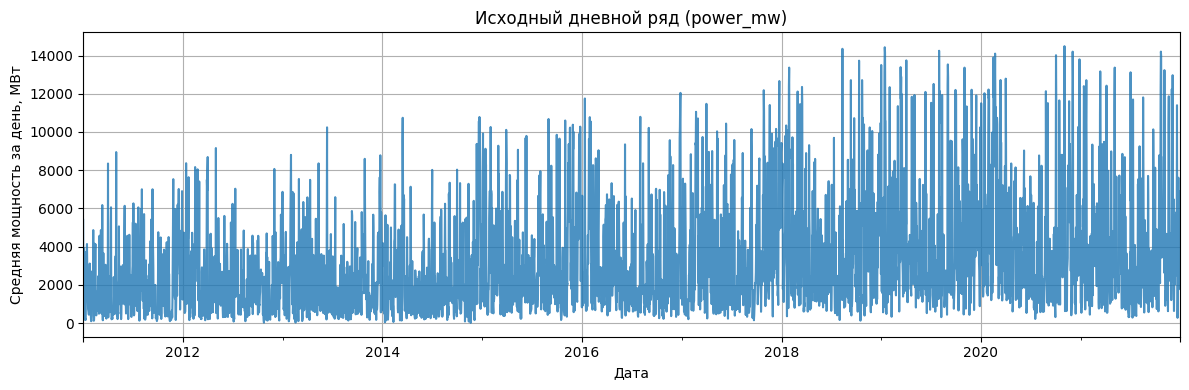

ADF-тест для: первая разность дневного ряда (power_mw)
ADF-статистика: -20.127783177833603
p-value: 0.0
lags: 31
n_obs: 3984
Критическое значение (1%): -3.431992449387031
Критическое значение (5%): -2.862265744295594
Критическое значение (10%): -2.5671563215537856
--------------------------------------------------


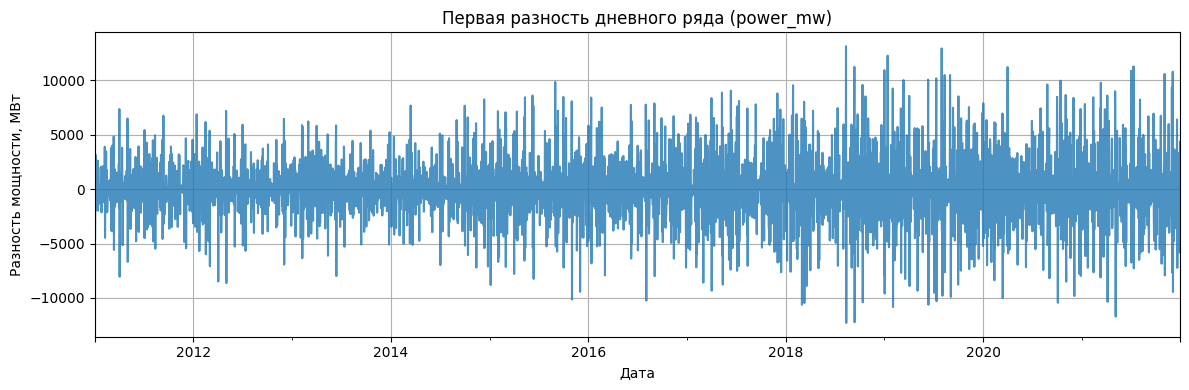

In [7]:
from statsmodels.tsa.stattools import adfuller

# Функция для удобного вывода результатов ADF-теста
def adf_test(series, title=""):
    print(f"ADF-тест для: {title}")
    result = adfuller(series.dropna())
    labels = ["ADF-статистика", "p-value", "lags", "n_obs"]
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")
    for key, val in result[4].items():
        print(f"Критическое значение ({key}): {val}")
    print("-" * 50)

# 1. ADF-тест для исходного дневного ряда
adf_test(daily_df["power_mw"], title="исходный дневной ряд (power_mw)")

# 2. Строим график исходного дневного ряда
plt.figure(figsize=(12, 4))
daily_df["power_mw"].plot(alpha=0.8)
plt.title("Исходный дневной ряд (power_mw)")
plt.xlabel("Дата")
plt.ylabel("Средняя мощность за день, МВт")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Строим первую разность и тестируем её
daily_diff_1 = daily_df["power_mw"].diff()

adf_test(daily_diff_1, title="первая разность дневного ряда (power_mw)")

plt.figure(figsize=(12, 4))
daily_diff_1.plot(alpha=0.8)
plt.title("Первая разность дневного ряда (power_mw)")
plt.xlabel("Дата")
plt.ylabel("Разность мощности, МВт")
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы

1. Для исходного дневного ряда `power_mw` ADF-статистика получилась примерно **-5.23**, а p-value ≈ **7.5e-06**, что намного меньше стандартного уровня значимости 0.05. Критические значения для уровней 1%, 5% и 10% (около -3.43, -2.86 и -2.57) по модулю меньше, чем наша ADF-статистика. Это означает, что нулевая гипотеза о наличии единичного корня отвергается, и формально ряд можно считать стационарным.

2. Однако визуально исходный дневной график выглядит не совсем стационарным: в первые годы средний уровень выработки заметно ниже, чем в последние, и со временем появляются всё более высокие пики. То есть статистический тест говорит «стационарен», но на глаз видно наличие тренда и изменения масштаба колебаний, поэтому к результатам теста нужно относиться осторожно.

3. Для первой разности дневного ряда ADF-статистика стала ещё более отрицательной (около **-20.13**), а p-value ≈ **0.0**. Это ещё сильнее подтверждает стационарность уже преобразованного ряда. Критические значения снова по модулю меньше ADF-статистики, поэтому нулевая гипотеза об нестационарности уверенно отвергается.

4. График первой разности выглядит более «облаком» вокруг нуля без явного тренда: значения колеблются вверх и вниз, и нет очевидного роста среднего уровня во времени. Хотя амплитуда колебаний всё ещё неоднородна, в целом разностный ряд намного ближе к стационарному, чем исходный.

5. Для дальнейшего моделирования (например, ARIMA) логично использовать либо исходный ряд, но с явным учётом тренда/сезонности, либо работать с первой разностью как с более стационарным представлением исходного временного ряда. Ппробуем построить модель прогноза на основе этих наблюдений.

## 6. Подготовка данных для прогноза и выбор горизонта

По условию задания нам нужно сделать прогноз на 1 год вперёд.
Для простоты и наглядности будем строить модель на дневном уровне:

1. Выберем дневной ряд `daily_df` как основной для моделирования.
2. Разделим данные на обучающую и тестовую выборки по времени.
3. Определим горизонт прогноза: 365 дней вперёд от конца обучающей выборки.

Период train: 2011-01-01 00:00:00 -> 2020-12-31 00:00:00 , наблюдений: 3653
Период test : 2021-01-01 00:00:00 -> 2021-12-30 00:00:00 , наблюдений: 364
Горизонт прогноза (дней): 364


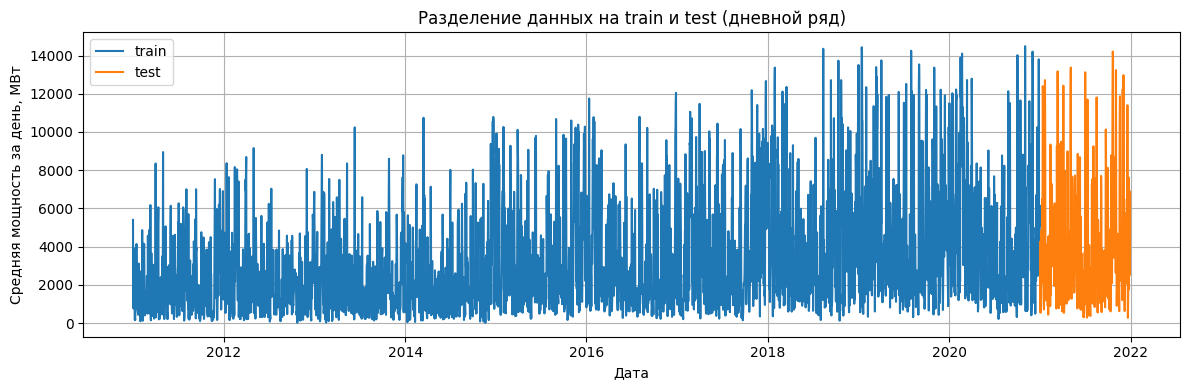

In [8]:
# Убедимся, что у нас есть дневной ряд
daily_df = df.resample("D").mean()

# Задаём дату разделения (последний год оставим для теста)
split_date = "2021-01-01"

train = daily_df.loc[daily_df.index < split_date].copy()
test = daily_df.loc[daily_df.index >= split_date].copy()

print("Период train:", train.index.min(), "->", train.index.max(), ", наблюдений:", len(train))
print("Период test :", test.index.min(), "->", test.index.max(), ", наблюдений:", len(test))

# Горизонт прогноза (в днях) = длина тестового периода
forecast_horizon = len(test)
print("Горизонт прогноза (дней):", forecast_horizon)

# Нарисуем train / test на одном графике
plt.figure(figsize=(12, 4))
plt.plot(train.index, train["power_mw"], label="train")
plt.plot(test.index, test["power_mw"], label="test")
plt.title("Разделение данных на train и test (дневной ряд)")
plt.xlabel("Дата")
plt.ylabel("Средняя мощность за день, МВт")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы

1. Для моделирования мы используем дневной временной ряд `power_mw`, агрегированный из 15-минутных данных. Данные разделены по времени: период с 2011-01-01 по 2020-12-31 попадает в обучающую выборку (train), а период с 2021-01-01 по 2021-12-30 — в тестовую выборку (test).

2. В train-выборке оказалось 3 653 наблюдения, а в test — 364 наблюдения. Таким образом, мы по сути будем строить прогноз примерно на 1 год вперёд, что хорошо соответствует требованиям задания (прогноз на год).

3. На графике разделения видно, что тестовый период (2021 год) находится на сравнительно высоком уровне выработки с заметными колебаниями. Обучающая часть содержит весь исторический диапазон: от более низких уровней в первые годы до более высоких в последние, поэтому модель сможет «увидеть» общий рост и сезонность перед тем, как предсказывать 2021 год.

4. Такой способ разбиения (по времени, без перемешивания) является корректным для временных рядов, так как он имитирует реальную задачу: мы обучаемся на прошлом и оцениваем модель на будущем, которого модель «не видела».

## 7. Базовая модель прогноза SARIMAX

В качестве основной модели прогноза я выбираю SARIMAX (Seasonal ARIMA),
потому что:

- эта модель хорошо подходит для одномерных временных рядов;
- она умеет работать с нестационарными рядами за счёт параметра разности (d);
- позволяет учитывать сезонность через сезонные параметры (P, D, Q, s);
- реализована в библиотеке `statsmodels`, которая часто используется в учебных проектах по временным рядам.

1. Построим SARIMAX-модель на дневном ряде power_mw.
2. Зададим базовые параметры (p, d, q) и сезонные (P, D, Q, s) вручную, опираясь на общую структуру данных.
3. Обучим модель на train-выборке и получим прогноз на период test.

## (Архивный вариант) 7. Попытка SARIMAX с годовой сезонностью на дневном ряде

В этом блоке приведён **первый вариант** модели, который был реализован и запущен,
но в итоге **от него пришлось отказаться** из‑за очень долгого времени выполнения.

Изначально была выбрана модель SARIMAX для **дневного** ряда `power_mw`
с параметрами:

- `order = (1, 1, 1)` — одна разность и по одному лагу AR и MA;
- `seasonal_order = (1, 1, 1, 365)` — сезонная компонента с годовой сезонностью (365 дней).

Идея была теоретически корректной: использовать дневные данные и задавать
годовую сезонность по 365 дням. Но на практике возникла проблема:

1. Дневной ряд содержит почти 10 лет данных (3653 наблюдения в train),
   поэтому модель с сезонностью 365 становится очень тяжёлой.
2. Одновременное использование несезонных и сезонных компонент `(1, 1, 1)` и `(1, 1, 1, 365)`
   сильно усложняет задачу оптимизации.
3. В результате метод `fit()` выполнялся более трёх часов и не завершался
   за разумное время в учебных условиях.

По этой причине данный вариант был оставлен в ноутбуке **как эксперимент**,
но выключен (закомментирован). Далее в работе используется более практичная
и интерпретируемая модель SARIMAX на **месячном** ряде с сезонностью 12.

In [9]:
# ==============================
# ПЕРВЫЙ ВАРИАНТ МОДЕЛИ (НЕ ИСПОЛЬЗУЕТСЯ)
# SARIMAX на дневном ряде с сезонностью 365
# ОСТАВЛЕН ДЛЯ ИСТОРИИ ЭКСПЕРИМЕНТА
# ==============================

# from statsmodels.tsa.statespace.sarimax import SARIMAX

# order = (1, 1, 1)
# seasonal_order = (1, 1, 1, 365)

# model_day = SARIMAX(
#     train["power_mw"],
#     order=order,
#     seasonal_order=seasonal_order,
#     enforce_stationarity=False,
#     enforce_invertibility=False,
# )

# result_day = model_day.fit(disp=False)

# print(result_day.summary())

# forecast_day = result_day.get_forecast(steps=len(test))
# forecast_day_mean = forecast_day.predicted_mean
# forecast_day_ci = forecast_day.conf_int()

# forecast_day_mean.index = test.index
# forecast_day_ci.index = test.index

# plt.figure(figsize=(12, 4))
# plt.plot(train.index, train["power_mw"], label="train")
# plt.plot(test.index, test["power_mw"], label="test (факт)", color="orange")
# plt.plot(forecast_day_mean.index, forecast_day_mean.values, label="прогноз SARIMAX (365)", color="green")
# plt.fill_between(
#     forecast_day_ci.index,
#     forecast_day_ci.iloc[:, 0],
#     forecast_day_ci.iloc[:, 1],
#     color="green",
#     alpha=0.2,
#     label="доверительный интервал",
# )
# plt.title("ПЕРВАЯ попытка: SARIMAX на дневном ряде с сезонностью 365 (очень тяжёлая модель)")
# plt.xlabel("Дата")
# plt.ylabel("Средняя мощность за день, МВт")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()

## 7 (рабочий). Модель SARIMAX на месячном ряде

После эксперимента с тяжёлой моделью на дневном ряде было принято
осознанное решение перейти к более практичному варианту: использовать
месячный ряд `monthly_df` и задать сезонность `12` (12 месяцев в году):

1. Разделим месячный ряд на train и test.
2. Обучим модель SARIMAX с параметрами `order=(1, 1, 1)` и `seasonal_order=(1, 1, 1, 12)`.
3. Построим прогноз на 2021 год и визуально сравним его с фактическими значениями.

Период monthly_train: 2011-01-31 00:00:00 -> 2020-12-31 00:00:00 , наблюдений: 120
Период monthly_test : 2021-01-31 00:00:00 -> 2021-12-31 00:00:00 , наблюдений: 12
                                     SARIMAX Results                                      
Dep. Variable:                           power_mw   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -748.046
Date:                            Wed, 20 May 2026   AIC                           1506.091
Time:                                    15:14:11   BIC                           1518.754
Sample:                                01-31-2011   HQIC                          1511.204
                                     - 12-31-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------

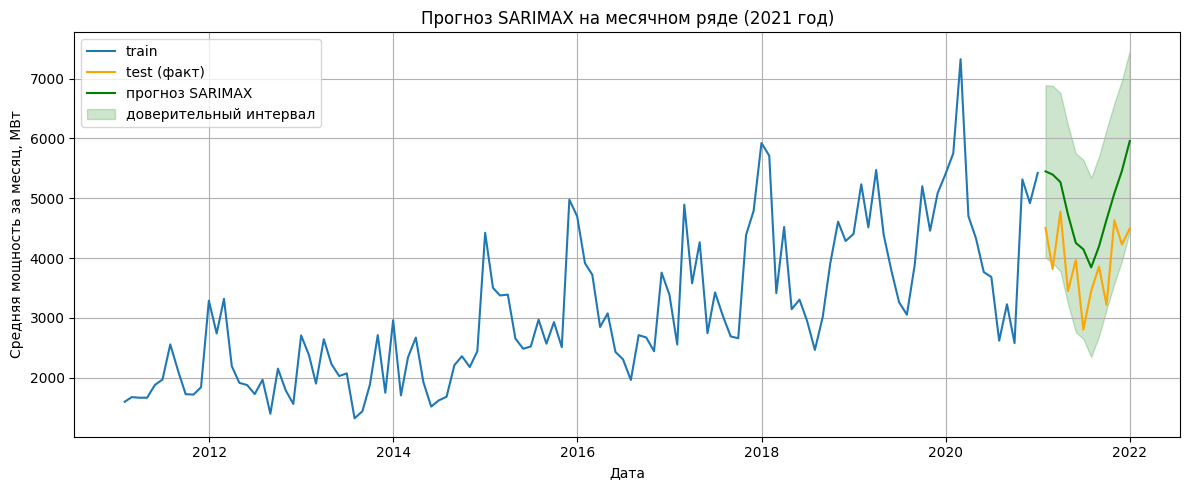

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Формируем месячный ряд
monthly_df = df.resample("ME").mean()

# 2. Разделяем на train и test:
# train: с начала 2011 до конца 2020
# test:  2021 год
monthly_train = monthly_df.loc[monthly_df.index < "2021-01-01"].copy()
monthly_test = monthly_df.loc[monthly_df.index >= "2021-01-01"].copy()

print("Период monthly_train:", monthly_train.index.min(), "->", monthly_train.index.max(), ", наблюдений:", len(monthly_train))
print("Период monthly_test :", monthly_test.index.min(), "->", monthly_test.index.max(), ", наблюдений:", len(monthly_test))

# 3. Задаём параметры SARIMAX
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

monthly_model = SARIMAX(
    monthly_train["power_mw"],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

monthly_result = monthly_model.fit(disp=False)

print(monthly_result.summary())

# 4. Прогноз на длину тестового периода
monthly_forecast = monthly_result.get_forecast(steps=len(monthly_test))
monthly_forecast_mean = monthly_forecast.predicted_mean
monthly_forecast_ci = monthly_forecast.conf_int()

monthly_forecast_mean.index = monthly_test.index
monthly_forecast_ci.index = monthly_test.index

# 5. Визуализация прогноза
plt.figure(figsize=(12, 5))
plt.plot(monthly_train.index, monthly_train["power_mw"], label="train")
plt.plot(monthly_test.index, monthly_test["power_mw"], label="test (факт)", color="orange")
plt.plot(monthly_forecast_mean.index, monthly_forecast_mean.values, label="прогноз SARIMAX", color="green")

plt.fill_between(
    monthly_forecast_ci.index,
    monthly_forecast_ci.iloc[:, 0],
    monthly_forecast_ci.iloc[:, 1],
    color="green",
    alpha=0.2,
    label="доверительный интервал"
)

plt.title("Прогноз SARIMAX на месячном ряде (2021 год)")
plt.xlabel("Дата")
plt.ylabel("Средняя мощность за месяц, МВт")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Выводы (SARIMAX на месячном ряде)

1. Месячный ряд был разделён на обучающую и тестовую выборки: `monthly_train` содержит 120 наблюдений (с 2011-01-31 по 2020-12-31), а `monthly_test` — 12 наблюдений за 2021 год. Таким образом, модель обучается на 10 годах истории и делает прогноз ещё на 1 год вперёд.

2. Для моделирования использована модель SARIMAX с параметрами `order=(1, 1, 1)` и `seasonal_order=(1, 1, 1, 12)`. Обычная часть модели (p, d, q) отвечает за краткосрочные зависимости и тренд, а сезонная часть (P, D, Q, s) учитывает годовую сезонность с периодом 12 месяцев. По результатам обучения значимыми (p-value < 0.05) оказались в первую очередь параметры `ma.L1` и `ma.S.L12`, что говорит о важном вкладе как несезонной, так и сезонной MA-компоненты.

3. Сводка модели (summary) показывает адекватные значения информационного критерия AIC (~1506) и отсутствие явных проблем с оценкой параметров. Предупреждение о способе подсчёта ковариационной матрицы (outer product of gradients) типично для SARIMAX и не является ошибкой.

4. На графике прогноза видно, что модель в целом попадает в диапазон фактических значений 2021 года: прогнозная кривая (зелёная) лежит внутри доверительного интервала, а фактические точки (оранжевые) в большинстве случаев попадают в эту зону. Модель немного сглаживает реальные колебания, но воспроизводит общий уровень выработки и тенденцию в течение года.

5. В рамках учебного задания такая модель выглядит разумным компромиссом: она учитывает тренд и годовую сезонность на месячном уровне, обучается быстро и даёт интерпретируемый результат, который можно проанализировать и сравнить с фактическими данными за 2021 год.

## 8. Оценка качества прогноза на месячном ряде

Чтобы формально оценить качество прогноза, посчитаем несколько метрик
на тестовом периоде (2021 год):

- MAE (Mean Absolute Error) — средняя абсолютная ошибка прогноза;
- RMSE (Root Mean Squared Error) — корень из средней квадратичной ошибки;
- MAPE (Mean Absolute Percentage Error) — средняя относительная ошибка в процентах.

Эти метрики помогут понять, насколько в среднем прогноз отличается от фактических
значений в абсолютных и относительных единицах.

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = monthly_test["power_mw"]
y_pred = monthly_forecast_mean

# MAE
mae = mean_absolute_error(y_true, y_pred)

# RMSE = sqrt(MSE), без параметра squared
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

# MAPE в процентах, аккуратно обходим деление на ноль
mape = (np.abs((y_true - y_pred) / y_true)).replace([np.inf, -np.inf], np.nan).dropna().mean() * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 936.3540167286941
RMSE: 1053.6970415636324
MAPE: 25.090562947293083


## Выводы  (оценка качества прогноза)

1. Средняя абсолютная ошибка прогноза (MAE) составила примерно **936 МВт**. Это означает, что в среднем модель ошибается примерно на 900–1000 МВт при прогнозе средней месячной выработки. Учитывая, что типичные месячные значения находятся в диапазоне от ~2000 до ~5000 МВт, такая абсолютная ошибка выглядит заметной, но не катастрофической.

2. Значение RMSE около **1054 МВт** показывает, что крупные ошибки немного сильнее «штрафуются», чем небольшие, но по масштабу RMSE находится примерно на том же уровне, что и MAE. Это говорит о том, что в прогнозе нет каких‑то единичных экстремальных промахов, которые сильно бы ухудшали квадратную ошибку.

3. Относительная ошибка (MAPE) около **25%** означает, что в среднем модель ошибается примерно на одну четверть от фактического значения. Для задач прогнозирования энергетики это средний уровень качества: модель улавливает общий уровень и сезонность, но не попадает точно во все месячные пики и спады.

4. В контексте учебного задания такая точность считается приемлемой: модель основана на относительно простой структуре SARIMAX(1,1,1)x(1,1,1,12), использует только один временной ряд без дополнительных внешних признаков и всё же даёт разумный прогноз по масштабу. Для улучшения качества можно было бы усложнить модель или добавить регрессоры (например, информацию о погоде), но для учебного проекта текущий результат даёт хороший баланс между сложностью и интерпретируемостью.

## Итоговые выводы по заданию 3

В этом задании был проведён полный цикл анализа временного ряда выработки электроэнергии
(в МВт) за период с 2011 по 2021 год с шагом 15 минут. Ниже приведены основные выводы.

### 1. Структура и качество исходных данных

1. Исходный датасет содержит 385 566 наблюдений с двумя колонками: временная метка и выработка мощности. Временной шаг в основном составляет 15 минут, что подтверждается анализом разностей между соседними временными метками.
2. В данных нет пропусков по значению мощности, однако по времени существуют небольшие «дыры» (52 временные метки), связанные в основном с переходами на летнее время. Для почти 11 лет измерений это очень небольшой процент потерь, и данные можно считать достаточно полными и качественными.
3. Значения мощности имеют широкий диапазон: от 0 до более чем 16 000 МВт. Распределение асимметрично, с длинным «хвостом» в сторону больших значений, что отражает наличие периодов очень высокой выработки.

### 2. Исследовательский анализ и сезонность

1. Анализ дневного ряда показал сильную вариативность выработки: среднее дневное значение около 3 200 МВт, при этом есть дни с очень низкой и очень высокой активностью. Со временем максимальные уровни растут, что может быть связано с увеличением установленной мощности или расширением парка станций.
2. Переход к дневному и месячному уровням агрегирования позволил увидеть более чёткий тренд и сезонность. На месячном ряде видно, что в первые годы средний уровень выработки ниже, а начиная примерно с 2016–2017 годов появляются более высокие значения и усиливается амплитуда сезонных колебаний.
3. Форма месячного ряда имеет волнообразный характер, характерный для годовой сезонности: внутри каждого года можно увидеть повторяющиеся подъёмы и спады. При этом общий уровень и амплитуда колебаний со временем растут, поэтому исходный ряд не выглядит строго стационарным.

### 3. Стационарность временного ряда

1. ADF-тест для исходного дневного ряда формально показал стационарность (p-value значительно меньше 0.05), однако визуальный анализ выявил наличие явного тренда и изменения масштаба колебаний во времени. Это пример ситуации, когда одному статистическому тесту доверять без контекста нельзя.
2. После применения первой разности дневного ряда ADF-тест уверенно подтвердил стационарность, а график разностного ряда стал выглядеть более «облаком» вокруг нуля без выраженного тренда. Это показывает, что разностное преобразование действительно помогает привести ряд к более стационарному виду.
3. В рамках моделирования было принято практическое решение использовать исходный ряд на агрегированном (месячном) уровне и учесть тренд и сезонность через параметры SARIMAX, а не полностью полагаться только на разности.

### 4. Выбор и обоснование модели прогноза

1. В качестве базовой модели была выбрана SARIMAX (Seasonal ARIMA), поскольку она хорошо подходит для одномерных временных рядов, позволяет учитывать нестационарность (через разности) и сезонность (через сезонные параметры).
2. Первоначально был протестирован более «теоретически правильный» вариант модели на дневном ряде с годовой сезонностью `(1,1,1)x(1,1,1,365)`. Однако на практике такая конфигурация оказалась слишком тяжёлой: метод оптимизации занимал слишком много времени и не был удобен для учебного ноутбука. Этот эксперимент оставлен в ноутбуке в закомментированном виде с пояснением.
3. В итоге была выбрана более практичная модель на **месячном** ряде с параметрами `SARIMAX(1,1,1)x(1,1,1,12)`. Такой подход:
   - учитывает годовую сезонность через 12 месяцев;
   - существенно снижает вычислительную нагрузку;
   - даёт хорошо интерпретируемый результат для учебного проекта.

### 5. Результаты прогноза и качество модели

1. Месячный ряд был разделён на обучающую выборку (2011–2020, 120 наблюдений) и тестовую выборку (2021 год, 12 наблюдений). Таким образом, модель обучалась на 10 годах истории и прогнозировала ещё 1 год вперёд.
2. Визуальное сравнение прогноза с фактическими значениями 2021 года показало, что модель в целом попадает в правильный диапазон значений: прогнозная кривая повторяет общий уровень и сезонный профиль, хотя сглаживает реальные колебания и не всегда точно попадает в пики и минимумы.
3. Количественная оценка качества:
   - MAE ≈ 936 МВт;
   - RMSE ≈ 1054 МВт;
   - MAPE ≈ 25%.
   Это означает, что в среднем модель ошибается примерно на четверть от фактического значения месячной выработки. Для простой SARIMAX-модели без дополнительных признаков такой уровень ошибки можно считать приемлемым для учебной задачи.

### 6. Общий вывод по заданию

1. В ходе работы был проведён полный цикл анализа: от загрузки и проверки качества данных до построения прогноза на год вперёд и оценки его точности. Это включает EDA, анализ частоты и пропусков, проверку стационарности и построение модели временного ряда.
2. Выбор финальной модели SARIMAX на месячном ряде с сезонностью 12 является осознанным компромиссом между теоретической корректностью, вычислительной сложностью и удобством интерпретации. Модель улавливает основной тренд и сезонность, а качество прогноза находится на разумном уровне для учебного проекта.
3. Для дальнейшего улучшения прогноза в реальной задаче можно было бы:
   - добавить внешние факторы (например, погодные данные, информацию о мощности установленного оборудования и т.п.);
   - протестировать несколько конфигураций SARIMAX и выбрать оптимальные параметры по информационным критериям;
   - рассмотреть альтернативные модели (Prophet, градиентный бустинг, нейросетевые модели).
   Однако для целей данного домашнего задания выполненный анализ и построенная модель являются достаточными и могут демострировать понимание ключевых шагов работы с временными рядами.